In [22]:

import numpy as np
import pandas as pd
import seaborn as sb
import matplotlib as mat
import matplotlib.pyplot as plt


cars = pd.read_csv('autos.csv', encoding="latin-1", on_bad_lines='skip')

print(cars.shape)
cars.head(-10)

(669126, 20)


/tmp/ipykernel_16467/3511810534.py:8: DtypeWarning: Columns (4,7,9,11,12,17,18) have mixed types. Specify dtype option on import or set low_memory=False.
  cars = pd.read_csv('autos.csv', encoding="latin-1", on_bad_lines='skip')


,dateCrawled,name,seller,offerType,price,abtest,vehicleType,yearOfRegistration,gearbox,powerPS,model,kilometer,monthOfRegistration,fuelType,brand,notRepairedDamage,dateCreated,nrOfPictures,postalCode,lastSeen
0,2016-03-24 11:52:17,Golf_3_1.6,privat,Angebot,480,test,NaN,1993,manuell,0.0,golf,150000,0,benzin,volkswagen,NaN,2016-03-24 00:00:00,0,70435.0,2016-04-07 03:16:57
1,2016-03-24 10:58:45,A5_Sportback_2.7_Tdi,privat,Angebot,18300,test,coupe,2011,manuell,190.0,NaN,125000,5,diesel,audi,ja,2016-03-24 00:00:00,0,66954.0,2016-04-07 01:46:50
2,2016-03-14 12:52:21,"Jeep_Grand_Cherokee_""Overland""",privat,Angebot,9800,test,suv,2004,automatik,163.0,grand,125000,8,diesel,jeep,NaN,2016-03-14 00:00:00,0,90480.0,2016-04-05 12:47:46
3,2016-03-17 16:54:04,GOLF_4_1_4__3TÜRER,privat,Angebot,1500,test,kleinwagen,2001,manuell,75.0,golf,150000,6,benzin,volkswagen,nein,2016-03-17 00:00:00,0,91074.0,2016-03-17 17:40:17
4,2016-03-31 17:25:20,Skoda_Fabia_1.4_TDI_PD_Classic,privat,Angebot,3600,test,kleinwagen,2008,manuell,69.0,fabia,90000,7,diesel,skoda,nein,2016-03-31 00:00:00,0,60437.0,2016-04-06 10:17:21
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
669111,2016-03-21 15:36:22,Seat_Leon_1.9_TDI_4/5_Tueren,privat,Angebot,4400,control,limousine,2008,manuell,105,leon,150000,7,diesel,seat,nein,2016-03-21 00:00:00,0,45896,2016-04-06 15:45:01
669112,2016-04-04 11:45:16,Renault_1_4_ltr.16_V_Megane_Cabrio,privat,Angebot,999,control,cabrio,2000,manuell,95,megane,150000,4,benzin,renault,NaN,2016-04-04 00:00:00,0,88477,2016-04-06 12:44:52
669113,2016-03-09 11:36:55,Skoda_Fabia_Kombi_1.4,privat,Angebot,1690,test,kombi,2004,manuell,55,fabia,150000,4,benzin,skoda,NaN,2016-03-09 00:00:00,0,18246,2016-04-04 08:15:30
669114,2016-04-04 09:57:12,Volkswagen_Lupo_1.0,privat,Angebot,1490,control,kleinwagen,1998,manuell,50,lupo,150000,9,benzin,volkswagen,nein,2016-04-04 00:00:00,0,48653,2016-04-06 11:17:13


In [30]:
cars['yearOfRegistration'] = pd.to_numeric(cars['yearOfRegistration'], errors='coerce')
cars['price'] = pd.to_numeric(cars['price'], errors='coerce')
cars['powerPS'] = pd.to_numeric(cars['powerPS'], errors='coerce')

cars = cars.dropna(subset=['yearOfRegistration', 'price'])

cars = cars[(cars["yearOfRegistration"] > 1900) & (cars["yearOfRegistration"] < 2024)]

print("Dados limpos com sucesso! Novo formato:", cars.shape)

Dados limpos com sucesso! Novo formato: (668768, 20)


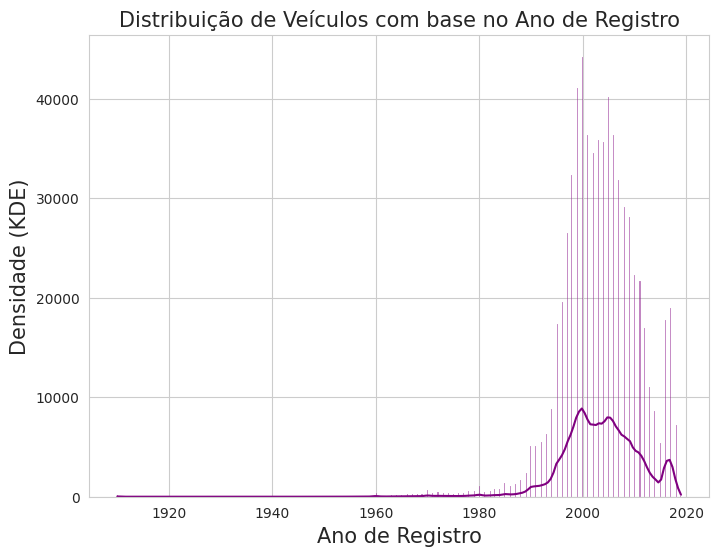

In [33]:
fig, ax = plt.subplots(figsize=(8,6))
sb.histplot(cars["yearOfRegistration"], color="purple", kde=True, ax=ax)
ax.set_title('Distribuição de Veículos com base no Ano de Registro', fontsize=15)
plt.ylabel("Densidade (KDE)", fontsize=15)
plt.xlabel("Ano de Registro", fontsize=15)
plt.show()

/tmp/ipykernel_16467/2263669943.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  graf = sb.catplot(x="vehicleType", data=cars, kind="count", palette="BuPu", height=6, aspect=1.5)


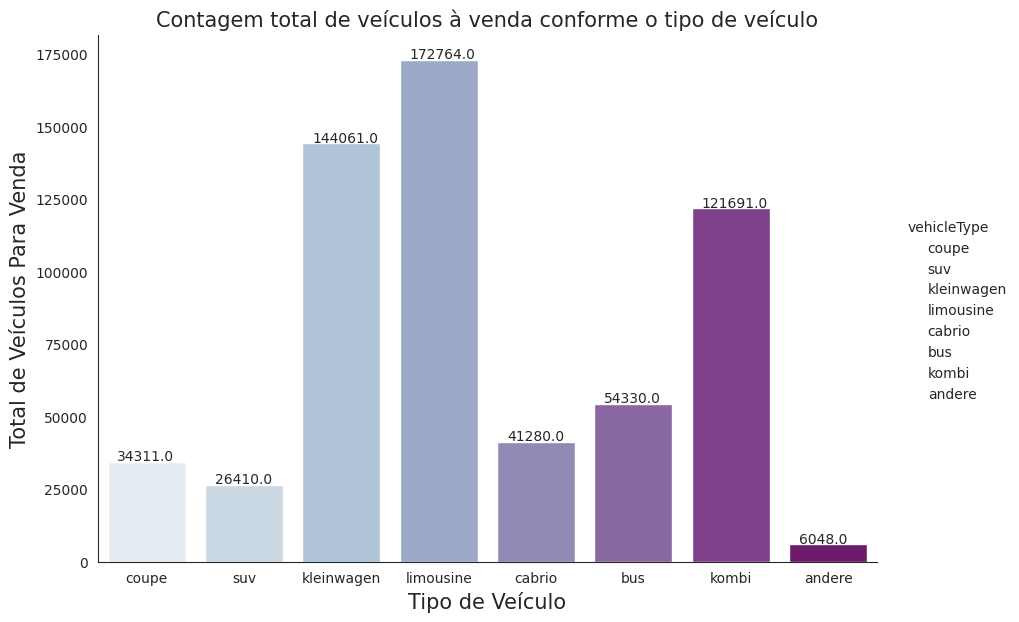

In [38]:
sb.set_style("white")
graf = sb.catplot(x="vehicleType", data=cars, kind="count", palette="BuPu", height=6, aspect=1.5)
graf.ax.xaxis.set_label_text("Tipo de Veículo", fontsize= 15)
graf.ax.yaxis.set_label_text("Total de Veículos Para Venda", fontsize= 15)
graf.ax.set_title("Contagem total de veículos à venda conforme o tipo de veículo", fontsize= 15)

for p in graf.ax.patches:
    graf.ax.annotate((p.get_height()), (p.get_x()+0.1, p.get_height()+500))

plt.show()

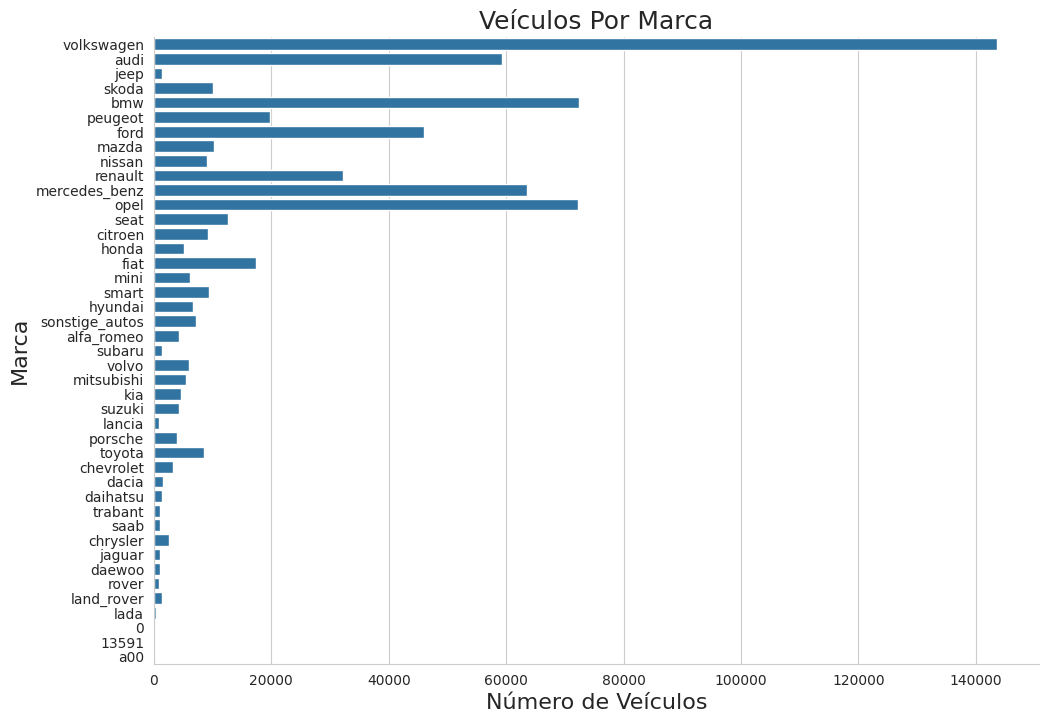

In [42]:
sb.set_style("whitegrid")
graf = sb.catplot(y="brand", data=cars, kind="count", height=7, aspect=1.5)
graf.ax.set_title("Veículos Por Marca",fontdict={'size':18})
graf.ax.xaxis.set_label_text("Número de Veículos",fontdict= {'size':16})
graf.ax.yaxis.set_label_text("Marca",fontdict= {'size':16})
plt.show()

/tmp/ipykernel_16467/4207694015.py:3: UserWarning: 
The palette list has fewer values (3) than needed (5) and will cycle, which may produce an uninterpretable plot.
  sb.barplot(x="vehicleType", y="price",hue="gearbox", palette=colors, data=cars)


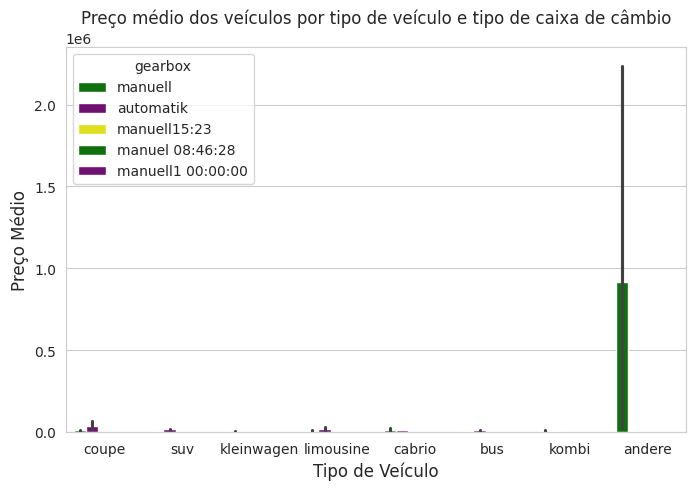

In [44]:
fig, ax = plt.subplots(figsize=(8,5))
colors = ["green", "purple","yellow"]
sb.barplot(x="vehicleType", y="price",hue="gearbox", palette=colors, data=cars)
ax.set_title("Preço médio dos veículos por tipo de veículo e tipo de caixa de câmbio",fontdict= {'size':12})
ax.xaxis.set_label_text("Tipo de Veículo",fontdict= {'size':12})
ax.yaxis.set_label_text("Preço Médio",fontdict= {'size':12})
plt.show()

/tmp/ipykernel_16467/608577666.py:3: UserWarning: The palette list has more values (3) than needed (2), which may not be intended.
  sb.barplot(x="gearbox", y="price",hue="seller", palette=colors, data=cars)


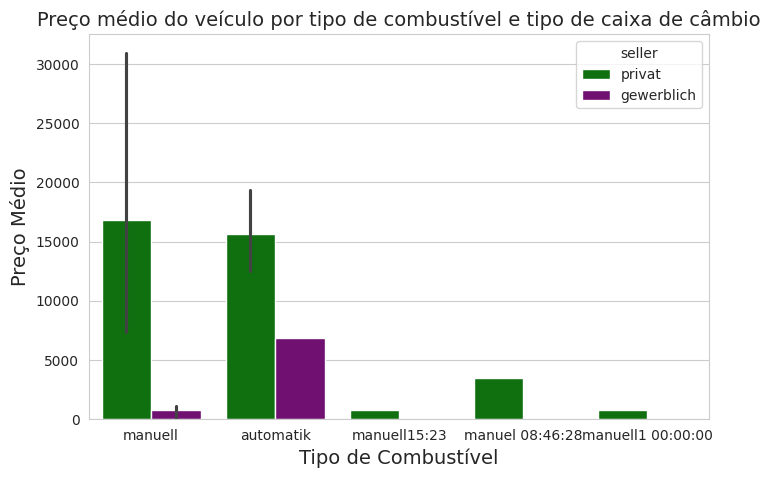

In [48]:
fig, ax = plt.subplots(figsize=(8,5))
colors = ["green", "purple","yellow"]
sb.barplot(x="gearbox", y="price",hue="seller", palette=colors, data=cars)
ax.set_title("Preço médio do veículo por tipo de combustível e tipo de caixa de câmbio",fontsize= 14)
ax.xaxis.set_label_text("Tipo de Combustível",fontsize= 14)
ax.yaxis.set_label_text("Preço Médio",fontsize= 14)
plt.show()

/tmp/ipykernel_16467/608577666.py:3: UserWarning: The palette list has more values (3) than needed (2), which may not be intended.
  sb.barplot(x="gearbox", y="price",hue="seller", palette=colors, data=cars)


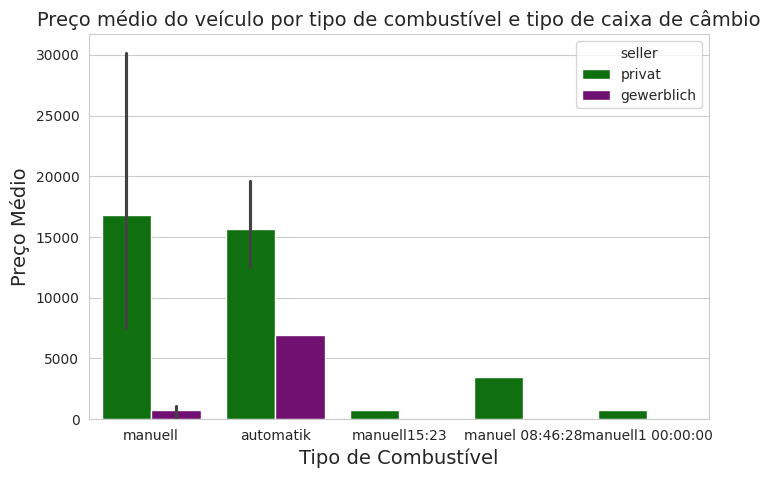

In [50]:
fig, ax = plt.subplots(figsize=(8,5))
colors = ["green", "purple","yellow"]
sb.barplot(x="gearbox", y="price",hue="seller", palette=colors, data=cars)
ax.set_title("Preço médio do veículo por tipo de combustível e tipo de caixa de câmbio",fontsize= 14)
ax.xaxis.set_label_text("Tipo de Combustível",fontsize= 14)
ax.yaxis.set_label_text("Preço Médio",fontsize= 14)
plt.show()

/tmp/ipykernel_16467/3442968330.py:3: UserWarning: 
The palette list has fewer values (3) than needed (5) and will cycle, which may produce an uninterpretable plot.
  sb.barplot(x="vehicleType", y="powerPS",hue="gearbox", palette=colors, data=cars)


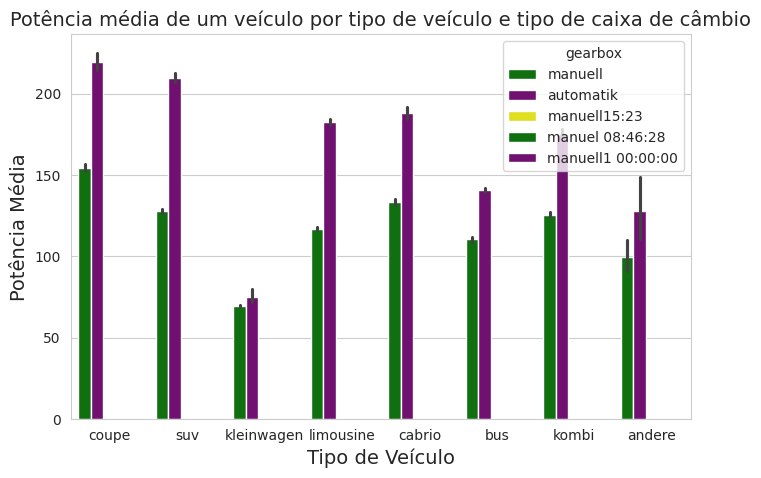

In [51]:
colors = ["green", "purple","yellow"]
fig, ax = plt.subplots(figsize=(8,5))
sb.barplot(x="vehicleType", y="powerPS",hue="gearbox", palette=colors, data=cars)
ax.set_title("Potência média de um veículo por tipo de veículo e tipo de caixa de câmbio",fontsize= 14)
ax.xaxis.set_label_text("Tipo de Veículo",fontsize= 14)
ax.yaxis.set_label_text("Potência Média",fontsize= 14)
plt.show()

In [53]:
lista_df =[]

for b in list(cars["brand"].unique()):
    for v in list(cars["vehicleType"].unique()):
        z = cars[(cars["brand"] == b) & (cars["vehicleType"] == v)]["price"].mean()
        lista_df.append(pd.DataFrame({'brand':b , 'vehicleType':v , 'avgPrice':z}, index=[0]))

mv = pd.concat(lista_df, ignore_index=True)

mv["avgPrice"] = mv["avgPrice"].fillna(0)
mv["avgPrice"] = mv["avgPrice"].astype(int)
mv.head(-10)

,brand,vehicleType,avgPrice
0,volkswagen,NaN,0
1,volkswagen,coupe,12324
2,volkswagen,suv,15922
3,volkswagen,kleinwagen,10001
4,volkswagen,limousine,11433
...,...,...,...
381,13591,kleinwagen,0
382,13591,limousine,0
383,13591,cabrio,0
384,13591,bus,0


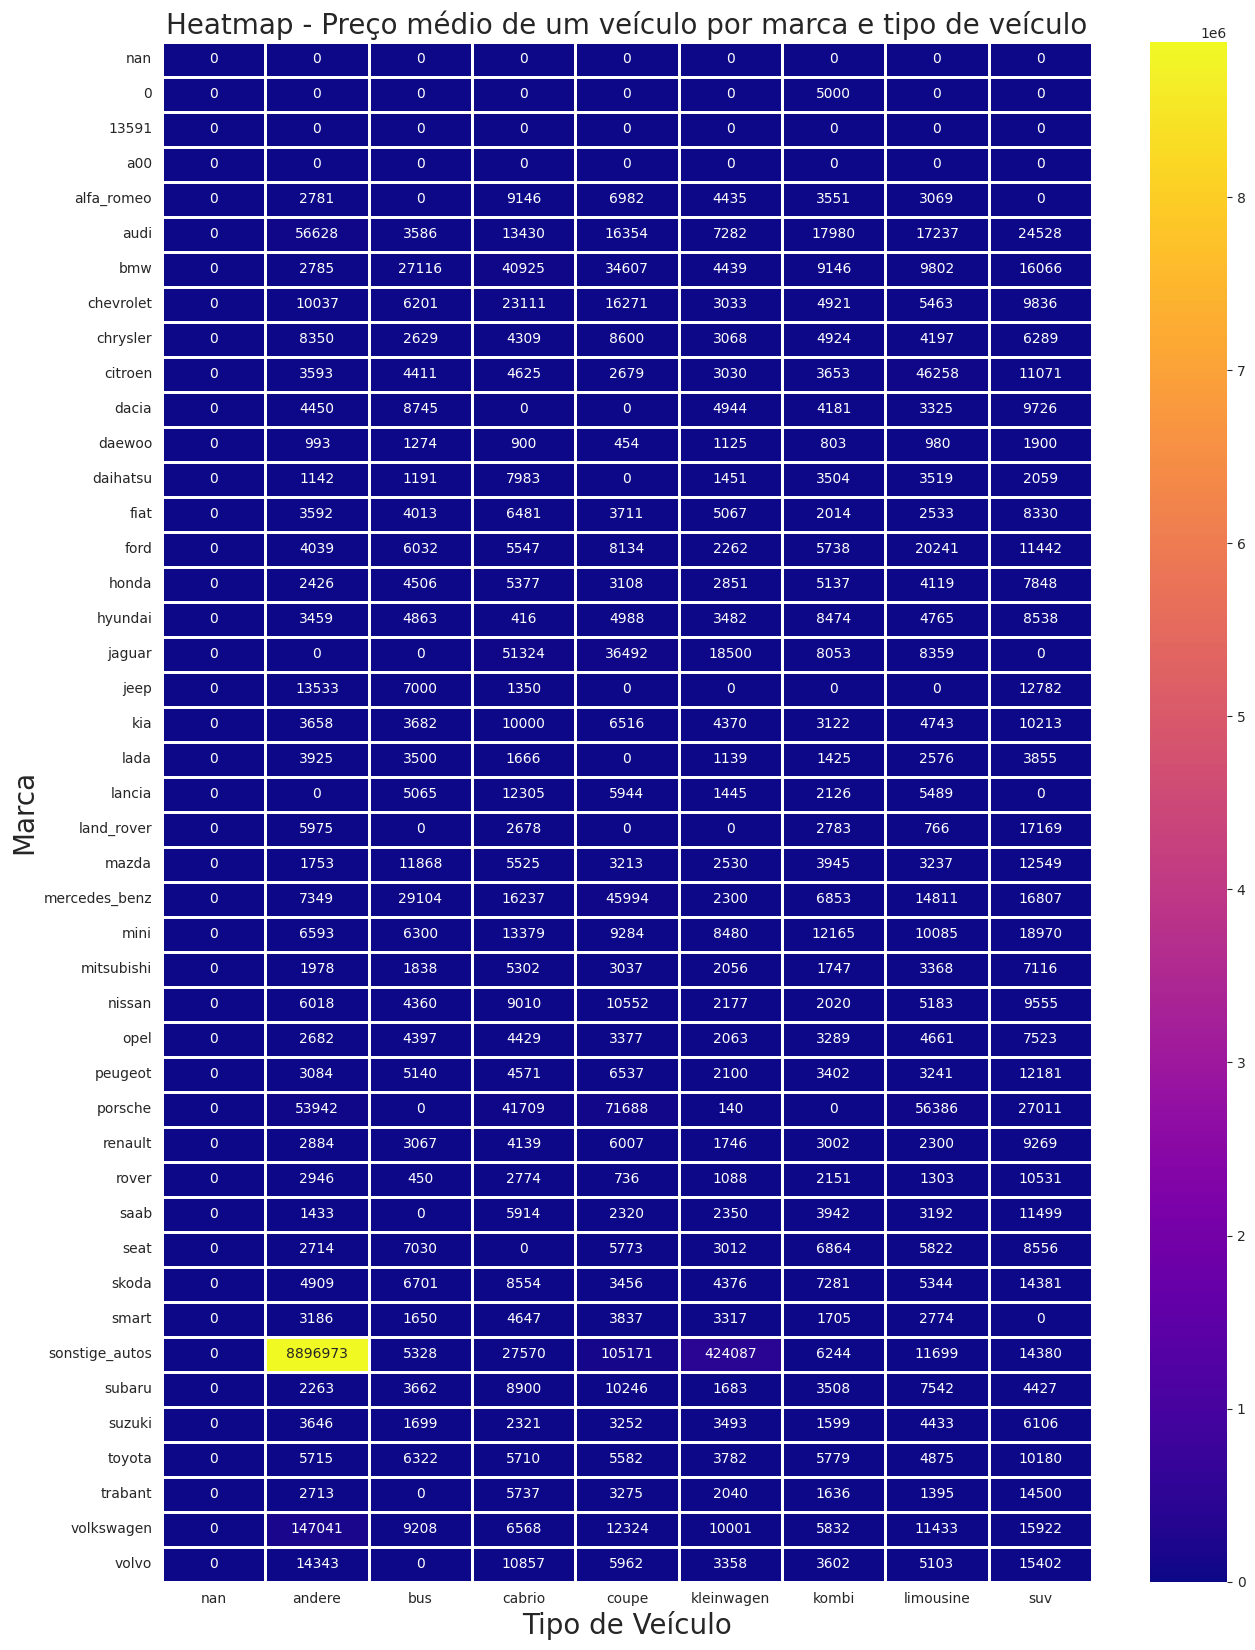

In [54]:
tri = mv.pivot(index="brand", columns="vehicleType", values="avgPrice")

fig, ax = plt.subplots(figsize=(15,20))
sb.heatmap(tri,linewidths=1,cmap="plasma",annot=True, ax=ax, fmt="d")
ax.set_title("Heatmap - Preço médio de um veículo por marca e tipo de veículo",fontsize=20)
ax.xaxis.set_label_text("Tipo de Veículo",fontsize=20)
ax.yaxis.set_label_text("Marca",fontsize=20)
plt.show()